In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

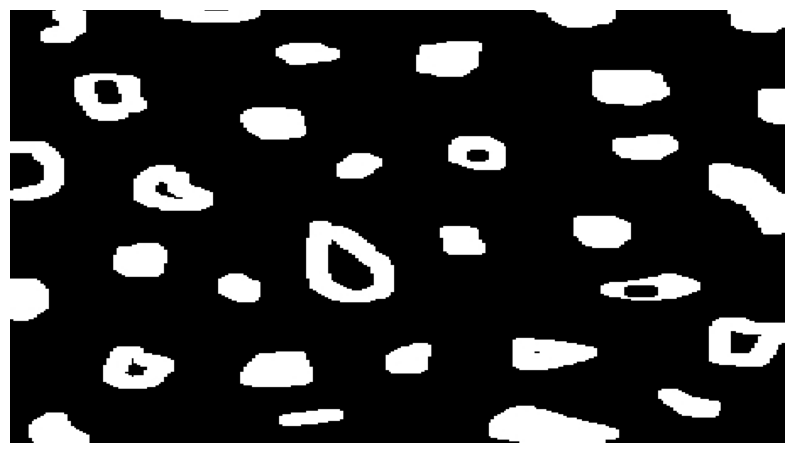

In [3]:
img = cv2.imread("../images/result_bubbles_original.png(1).jpeg")
plt.figure(figsize=(10,10))
plt.imshow(img[...,::-1]);plt.axis('off');

Full circles count: 24
Empty circles count: 8


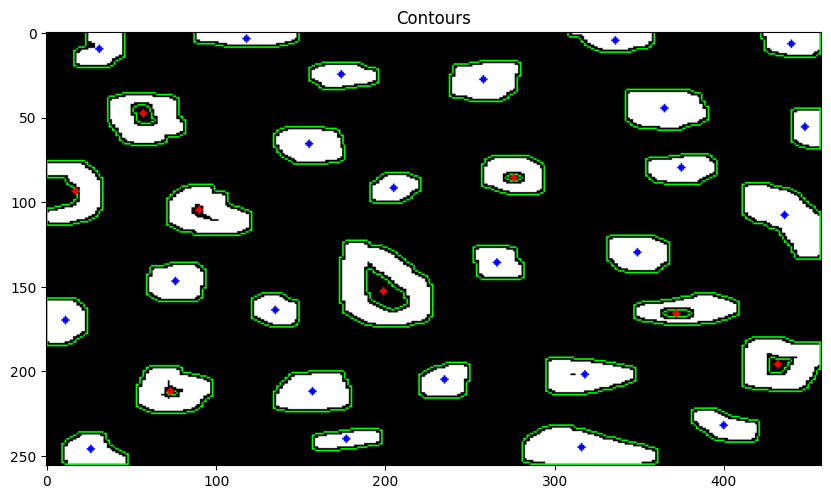

In [45]:
img_copy = img.copy()
img_gray = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)
img_blur = cv2.GaussianBlur(img_gray, (5,5), 0)
contours, hierarchy = cv2.findContours(img_blur, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
result = cv2.drawContours(img_copy, contours, -1, (0,255,0), 1)

full_count = 0
empty_count = 0

if hierarchy is not None:
    hierarchy = hierarchy[0]  

    for i, c in enumerate(contours):
        M = cv2.moments(c)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])

            if hierarchy[i][2] == -1:
                if img_blur[cy, cx] > 127:  
                    full_count += 1
                    cv2.circle(result, (cx, cy), 2, (255, 0, 0), -1)
                else:
                    empty_count += 1
                    cv2.circle(result, (cx, cy), 2, (0, 0, 255), -1)

print("Full circles count:", full_count)
print("Empty circles count:", empty_count)
plt.figure(figsize=(10,10))
plt.imshow(result[...,::-1]);plt.title("Contours");